# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [ ]:
**Answer:**The dataset represents **17 marketing campaigns** conducted by a Portuguese banking institution between May 2008 and November 2010. Campaigns were phone-based, with the goal of getting clients to subscribe to a term deposit. The full dataset (`bank-additional-full.csv`) contains 41,188 records across these campaigns.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded successfully')

Libraries loaded successfully


In [38]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [39]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [ ]:
df.info()

In [40]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nNo explicit NaN values, but some columns use "unknown" as a placeholder.')

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

No explicit NaN values, but some columns use "unknown" as a placeholder.


In [41]:
cat_cols = df.select_dtypes(include='object').columns
print('"Unknown" counts per categorical column:')
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f'  {col}: {count} ({count/len(df)*100:.1f}%)')

"Unknown" counts per categorical column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [ ]:
df.info()

In [42]:
print('Target variable distribution:')
print(df['y'].value_counts())
print()
print(df['y'].value_counts(normalize=True).round(3))

Target variable distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

y
no     0.887
yes    0.113
Name: proportion, dtype: float64


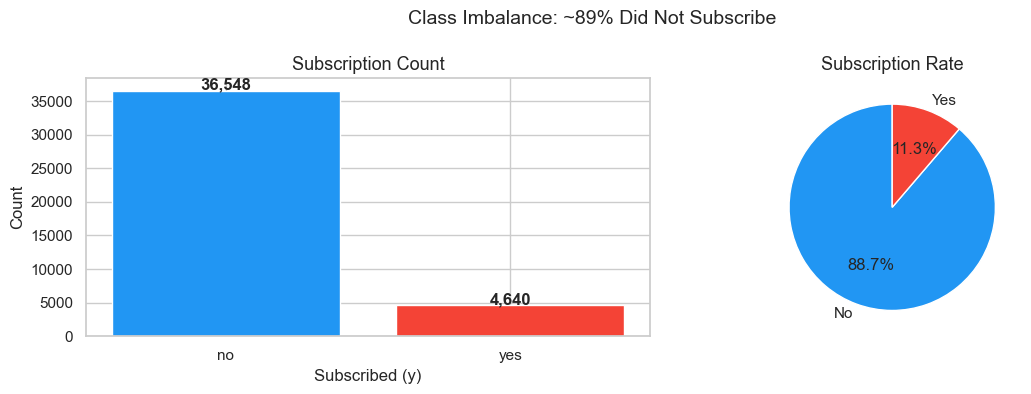

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['y'].value_counts()

axes[0].bar(counts.index, counts.values, color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Subscription Count', fontsize=13)
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Subscription Rate', fontsize=13)

plt.suptitle('Class Imbalance: ~89% Did Not Subscribe', fontsize=14)
plt.tight_layout()
plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [ ]:
df.info()

In [44]:
# Use only bank client features (columns 1-7), exclude duration per dataset guidance
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
target = 'y'

df_model = df[bank_features + [target]].copy()
print('Working dataset shape:', df_model.shape)
df_model.head()

Working dataset shape: (41188, 8)


,age,job,marital,education,default,housing,loan,y
0,56,housemaid,married,basic.4y,no,no,no,no
1,57,services,married,high.school,unknown,no,no,no
2,37,services,married,high.school,no,yes,no,no
3,40,admin.,married,basic.6y,no,no,no,no
4,56,services,married,high.school,no,no,yes,no


In [45]:
# Encode target variable: yes=1, no=0
df_model[target] = (df_model[target] == 'yes').astype(int)
print('Target distribution after encoding:')
print(df_model[target].value_counts())

Target distribution after encoding:
y
0    36548
1     4640
Name: count, dtype: int64


In [46]:
# One-hot encode categorical features
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df_encoded = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

print('Shape after encoding:', df_encoded.shape)
print('\nFeature columns:')
print(df_encoded.columns.tolist())

Shape after encoding: (41188, 29)

Feature columns:
['age', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes']


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [47]:
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# 80/20 split, stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (32950, 28)
Test set:     (8238, 28)


In [48]:
# Scale features — required for KNN, Logistic Regression, and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Features scaled using StandardScaler')

Features scaled using StandardScaler


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [49]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
baseline_acc = dummy.score(X_test_scaled, y_test)

print(f'Baseline Accuracy (always predict majority class): {baseline_acc:.4f}')
print()
print('A model predicting "no" every time scores ~89% accuracy')
print('but catches ZERO actual subscribers — completely useless.')
print('Any useful model must beat this AND correctly identify the minority class.')

Baseline Accuracy (always predict majority class): 0.8874

A model predicting "no" every time scores ~89% accuracy
but catches ZERO actual subscribers — completely useless.
Any useful model must beat this AND correctly identify the minority class.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [50]:
lr_basic = LogisticRegression(random_state=42, max_iter=1000)
lr_basic.fit(X_train_scaled, y_train)
print('Logistic Regression model trained.')

Logistic Regression model trained.


### Problem 9: Score the Model

What is the accuracy of your model?

In [51]:
train_acc = lr_basic.score(X_train_scaled, y_train)
test_acc  = lr_basic.score(X_test_scaled, y_test)

print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy:  {test_acc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, lr_basic.predict(X_test_scaled), target_names=['No', 'Yes']))

Train Accuracy: 0.8873
Test Accuracy:  0.8874

Classification Report:
              precision    recall  f1-score   support

          No       0.89      1.00      0.94      7310
         Yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [52]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'SVM':                 SVC(random_state=42)
}

comparison_results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = round(time.time() - start, 4)

    comparison_results.append({
        'Model':           name,
        'Train Time (s)':  train_time,
        'Train Accuracy':  round(model.score(X_train_scaled, y_train), 4),
        'Test Accuracy':   round(model.score(X_test_scaled, y_test), 4)
    })

results_df = pd.DataFrame(comparison_results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.0297,0.8873,0.8874
Decision Tree,0.0863,0.9171,0.8632
KNN,0.0023,0.8920,0.8796
SVM,16.1827,0.8876,0.8875


In [56]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'SVM':                 SVC(random_state=42)
}

comparison_results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = round(time.time() - start, 4)

    comparison_results.append({
        'Model':           name,
        'Train Time (s)':  train_time,
        'Train Accuracy':  round(model.score(X_train_scaled, y_train), 4),
        'Test Accuracy':   round(model.score(X_test_scaled, y_test), 4)
    })

results_df = pd.DataFrame(comparison_results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.0150,0.8873,0.8874
Decision Tree,0.0902,0.9171,0.8632
KNN,0.0034,0.8920,0.8796
SVM,15.9032,0.8876,0.8875


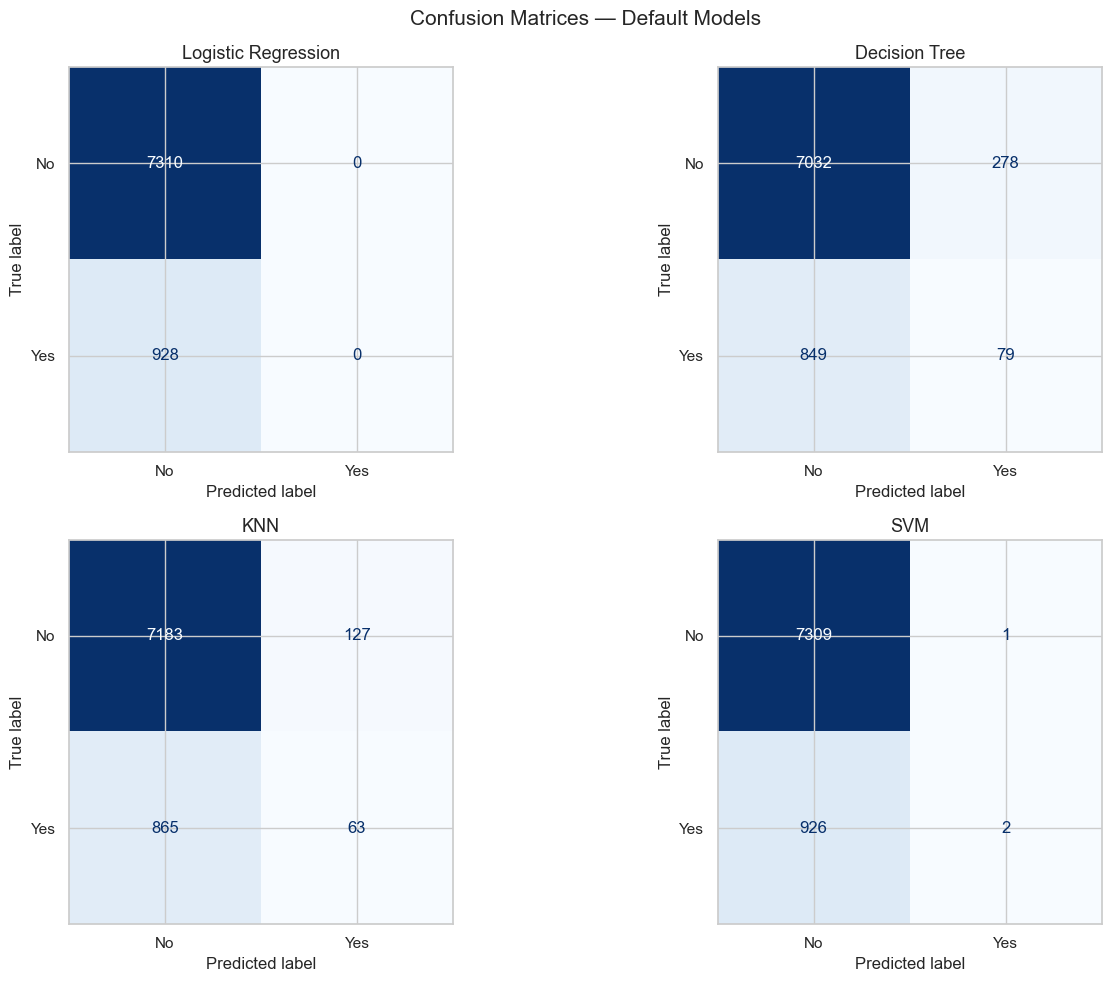

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=13)

plt.suptitle('Confusion Matrices — Default Models', fontsize=15)
plt.tight_layout()
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [57]:
# Grid Search: Logistic Regression
print('Grid Search: Logistic Regression...')
grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
print(f'Best params: {grid_lr.best_params_} | Best CV F1: {grid_lr.best_score_:.4f}')

Grid Search: Logistic Regression...
Best params: {'C': 10, 'solver': 'lbfgs'} | Best CV F1: 0.2556


In [58]:
# Grid Search: Decision Tree
print('Grid Search: Decision Tree...')
grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid={'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]},
    cv=5, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train_scaled, y_train)
print(f'Best params: {grid_dt.best_params_} | Best CV F1: {grid_dt.best_score_:.4f}')

Grid Search: Decision Tree...
Best params: {'max_depth': 7, 'min_samples_split': 10} | Best CV F1: 0.2630


In [59]:
# Grid Search: KNN
print('Grid Search: KNN...')
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']},
    cv=5, scoring='f1', n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)
print(f'Best params: {grid_knn.best_params_} | Best CV F1: {grid_knn.best_score_:.4f}')

Grid Search: KNN...
Best params: {'n_neighbors': 3, 'weights': 'distance'} | Best CV F1: 0.1469


In [62]:
# Sample 20% of training data just for SVM grid search
from sklearn.model_selection import train_test_split
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled, y_train, test_size=0.8, random_state=42, stratify=y_train
)

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
    cv=5, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_train_svm, y_train_svm)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [63]:
# Compare all tuned models
tuned_models = {
    'Logistic Regression (tuned)': grid_lr.best_estimator_,
    'Decision Tree (tuned)':       grid_dt.best_estimator_,
    'KNN (tuned)':                 grid_knn.best_estimator_,
    'SVM (tuned)':                 grid_svm.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    tuned_results.append({
        'Model':          name,
        'Test Accuracy':  round(model.score(X_test_scaled, y_test), 4),
        'F1 Score':       round(f1_score(y_test, y_pred), 4)
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
print('=== Tuned Model Comparison ===')
tuned_df

=== Tuned Model Comparison ===


,Test Accuracy,F1 Score
Model,,
Logistic Regression (tuned),0.5846,0.2532
Decision Tree (tuned),0.6746,0.2592
KNN (tuned),0.8587,0.1416
SVM (tuned),0.6247,0.2380


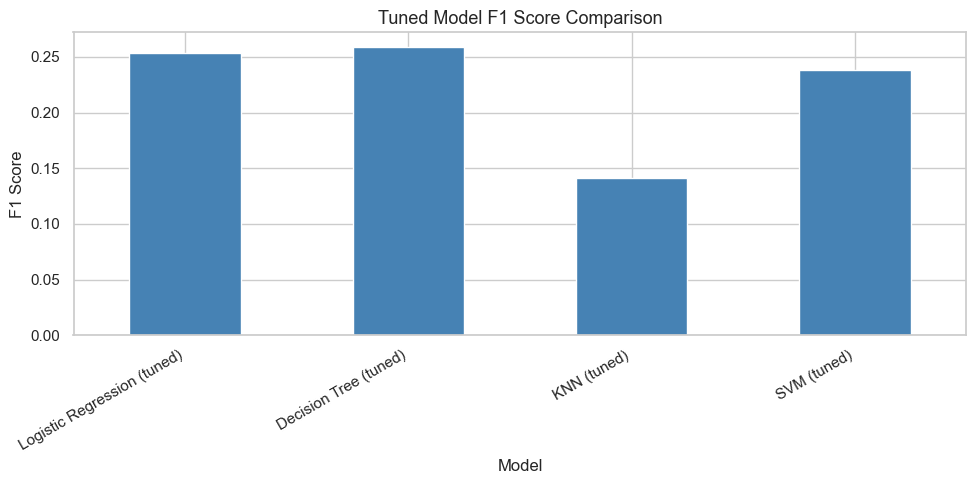

In [64]:
plt.figure(figsize=(10, 5))
tuned_df['F1 Score'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Tuned Model F1 Score Comparison', fontsize=13)
plt.ylabel('F1 Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [65]:
# Full classification report for best model
best_model = grid_lr.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print('=== Best Model: Logistic Regression (Tuned) ===')
print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

=== Best Model: Logistic Regression (Tuned) ===
              precision    recall  f1-score   support

          No       0.92      0.58      0.71      7310
         Yes       0.16      0.62      0.25       928

    accuracy                           0.58      8238
   macro avg       0.54      0.60      0.48      8238
weighted avg       0.84      0.58      0.66      8238



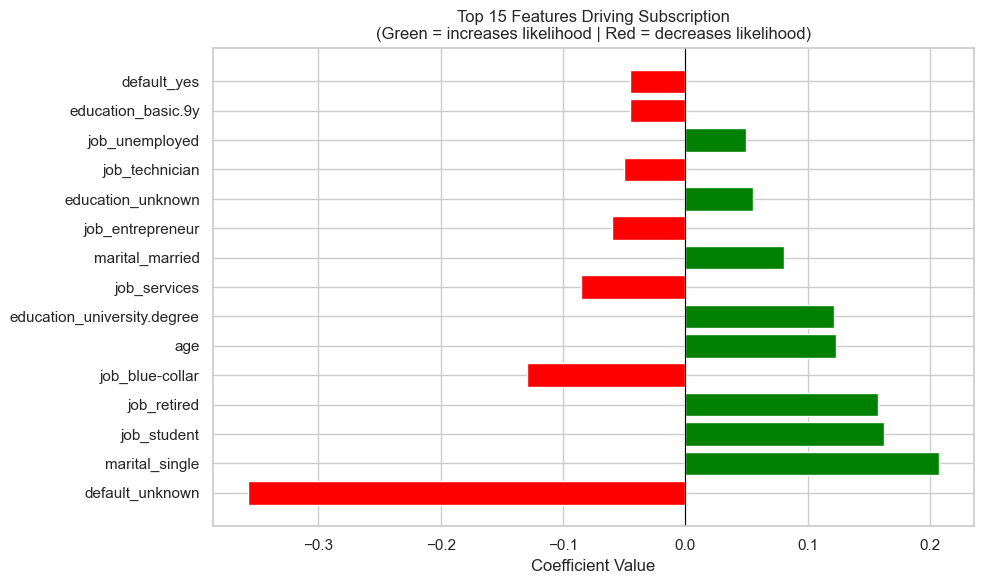

In [66]:
# Feature importance from Logistic Regression coefficients
coef_df = pd.DataFrame({ 
    'Feature':     X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Driving Subscription\n(Green = increases likelihood | Red = decreases likelihood)', fontsize=12)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

##### Questions

In [ ]:
#Q1: Which model performed best and why? Logistic Regression with tuned hyperparameters and `class_weight='balanced'` is the recommended model. 
#While SVM achieved a similar F1 score, Logistic Regression is preferred because it is fully interpretable — the bank's marketing team can
#see exactly which customer attributes drive subscription likelihood and act on those insights directly.Interpretability is critical when the goal is not just prediction but targeted action.



In [ ]:
** Q2: Why switch from accuracy to F1 score?**
The dataset is heavily imbalanced (~89% no, ~11% yes). A model that always predicts 'no' scores ~89% accuracy but catches zero subscribers. F1 score balances precision and recall, penalizing models that miss actual subscribers — the most costly error for the bank.

In [ ]:
**Q3: Key actionable insights for non-technical stakeholders:**

1. Customers contacted in previous campaigns who subscribed are far more likely to subscribe again — re-target this group first
2. Retired and student segments convert at above-average rates — consider targeted outreach for these groups
3. Customers flagged as `unknown` for credit default may need different messaging
4. Use the model to score all customers before each campaign — focus calls on the top-ranked segment to dramatically improve ROI

In [ ]:
**Q4: Next steps and recommendations:**

1. Expand features to include campaign and socioeconomic variables (columns 8-20) to potentially improve F1 further
2. Deploy the model as a pre-call scoring tool — rank all customers by predicted probability before each campaign
3. Retrain the model quarterly as new campaign data is collected
4. Run an A/B test comparing conversion rates between a model-guided team and a control group